### Указать пути и параметры

In [2]:
# === Параметры ===
BASE_FOLDER = "split_windows_512"  # папка с окнами (подпапки = номера датасетов)
EXCLUDE_DATASETS = {11, 25, 19, 21, 17, 15, 23, 27, 31}    # номера датасетов, которые исключаем (обрыв фаз и т.п.)
WINDOW_SIZE = 256              # только для подписи, не обязательно
TOP_N = 10                     # сколько аномальных окон показать

# Isolation Forest
CONTAMINATION = 0.03           # доля аномалий (подбери)
RANDOM_STATE = 42

### Импорты и вспомогательные функции

In [6]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.stats import zscore
from sklearn.ensemble import IsolationForest
from scipy.signal import hilbert
from numpy.fft import rfft, rfftfreq
import matplotlib.pyplot as plt

In [12]:
def read_window_csv(path):
    """Безопасное чтение окна."""
    df = pd.read_csv(path)
    return df[["current_R", "current_S", "current_T"]]

In [7]:
def rms(x):
    return np.sqrt(np.mean(x**2))

def amplitude_imbalance(rms_vals):
    return (np.max(rms_vals) - np.min(rms_vals)) / (np.mean(rms_vals) + 1e-9)

def corr_coef(a, b):
    # если есть постоянная линия/нулевая дисперсия, возвращаем 0
    if np.std(a) < 1e-9 or np.std(b) < 1e-9:
        return 0.0
    return np.corrcoef(a, b)[0,1]

def std_of_diff(a, b):
    return np.std(a - b)

def phase_diff_metric(R, S, T):
    """Твоя метрика phase_diff (среднее |разность|)."""
    return (np.abs(R - S).mean() + np.abs(S - T).mean() + np.abs(T - R).mean())

def hilbert_phase_delay(a, b):
    """Оценка среднего фазового сдвига через аналитические сигналы."""
    # Комплексные огибающие
    ha = hilbert(a)
    hb = hilbert(b)
    phase_a = np.unwrap(np.angle(ha))
    phase_b = np.unwrap(np.angle(hb))
    # Mean phase diff (в радианах)
    return np.mean((phase_a - phase_b))

def spectral_energy(signal, fs, f_lo, f_hi):
    """Энергия спектра в полосе [f_lo, f_hi] Гц."""
    N = len(signal)
    spec = np.abs(rfft(signal))**2
    freqs = rfftfreq(N, 1/fs)
    mask = (freqs >= f_lo) & (freqs <= f_hi)
    return spec[mask].sum()

def negative_sequence_index(R, S, T):
    """
    Индекс отрицательной последовательности (по форте́скью).
    Считаем на основе мгновенных значений как грубую оценку.
    Берём комплексные аналитические сигналы и считаем «phasor» через среднюю амплитуду.
    """
    # Аналитический сигнал ~ комплексная огибающая
    hR, hS, hT = hilbert(R), hilbert(S), hilbert(T)
    # усреднённые «фазоры»
    vR = np.mean(hR)
    vS = np.mean(hS)
    vT = np.mean(hT)
    a = np.exp(1j*2*np.pi/3)
    I_pos  = (vR + a * vS + a**2 * vT) / 3
    I_neg  = (vR + a**2 * vS + a * vT) / 3
    # индекс отрицательной последовательности
    return np.abs(I_neg) / (np.abs(I_pos) + 1e-9)


In [8]:
def rms(x):
    return np.sqrt(np.mean(x**2))

def amplitude_imbalance(rms_vals):
    return (np.max(rms_vals) - np.min(rms_vals)) / (np.mean(rms_vals) + 1e-9)

def corr_coef(a, b):
    # если есть постоянная линия/нулевая дисперсия, возвращаем 0
    if np.std(a) < 1e-9 or np.std(b) < 1e-9:
        return 0.0
    return np.corrcoef(a, b)[0,1]

def std_of_diff(a, b):
    return np.std(a - b)

def phase_diff_metric(R, S, T):
    """Твоя метрика phase_diff (среднее |разность|)."""
    return (np.abs(R - S).mean() + np.abs(S - T).mean() + np.abs(T - R).mean())

def hilbert_phase_delay(a, b):
    """Оценка среднего фазового сдвига через аналитические сигналы."""
    # Комплексные огибающие
    ha = hilbert(a)
    hb = hilbert(b)
    phase_a = np.unwrap(np.angle(ha))
    phase_b = np.unwrap(np.angle(hb))
    # Mean phase diff (в радианах)
    return np.mean((phase_a - phase_b))

def spectral_energy(signal, fs, f_lo, f_hi):
    """Энергия спектра в полосе [f_lo, f_hi] Гц."""
    N = len(signal)
    spec = np.abs(rfft(signal))**2
    freqs = rfftfreq(N, 1/fs)
    mask = (freqs >= f_lo) & (freqs <= f_hi)
    return spec[mask].sum()

def negative_sequence_index(R, S, T):
    """
    Индекс отрицательной последовательности (по форте́скью).
    Считаем на основе мгновенных значений как грубую оценку.
    Берём комплексные аналитические сигналы и считаем «phasor» через среднюю амплитуду.
    """
    # Аналитический сигнал ~ комплексная огибающая
    hR, hS, hT = hilbert(R), hilbert(S), hilbert(T)
    # усреднённые «фазоры»
    vR = np.mean(hR)
    vS = np.mean(hS)
    vT = np.mean(hT)
    a = np.exp(1j*2*np.pi/3)
    I_pos  = (vR + a * vS + a**2 * vT) / 3
    I_neg  = (vR + a**2 * vS + a * vT) / 3
    # индекс отрицательной последовательности
    return np.abs(I_neg) / (np.abs(I_pos) + 1e-9)


In [9]:
def rms(x):
    return np.sqrt(np.mean(x**2))

def amplitude_imbalance(rms_vals):
    return (np.max(rms_vals) - np.min(rms_vals)) / (np.mean(rms_vals) + 1e-9)

def corr_coef(a, b):
    # если есть постоянная линия/нулевая дисперсия, возвращаем 0
    if np.std(a) < 1e-9 or np.std(b) < 1e-9:
        return 0.0
    return np.corrcoef(a, b)[0,1]

def std_of_diff(a, b):
    return np.std(a - b)

def phase_diff_metric(R, S, T):
    """Твоя метрика phase_diff (среднее |разность|)."""
    return (np.abs(R - S).mean() + np.abs(S - T).mean() + np.abs(T - R).mean())

def hilbert_phase_delay(a, b):
    """Оценка среднего фазового сдвига через аналитические сигналы."""
    # Комплексные огибающие
    ha = hilbert(a)
    hb = hilbert(b)
    phase_a = np.unwrap(np.angle(ha))
    phase_b = np.unwrap(np.angle(hb))
    # Mean phase diff (в радианах)
    return np.mean((phase_a - phase_b))

def spectral_energy(signal, fs, f_lo, f_hi):
    """Энергия спектра в полосе [f_lo, f_hi] Гц."""
    N = len(signal)
    spec = np.abs(rfft(signal))**2
    freqs = rfftfreq(N, 1/fs)
    mask = (freqs >= f_lo) & (freqs <= f_hi)
    return spec[mask].sum()

def negative_sequence_index(R, S, T):
    """
    Индекс отрицательной последовательности (по форте́скью).
    Считаем на основе мгновенных значений как грубую оценку.
    Берём комплексные аналитические сигналы и считаем «phasor» через среднюю амплитуду.
    """
    # Аналитический сигнал ~ комплексная огибающая
    hR, hS, hT = hilbert(R), hilbert(S), hilbert(T)
    # усреднённые «фазоры»
    vR = np.mean(hR)
    vS = np.mean(hS)
    vT = np.mean(hT)
    a = np.exp(1j*2*np.pi/3)
    I_pos  = (vR + a * vS + a**2 * vT) / 3
    I_neg  = (vR + a**2 * vS + a * vT) / 3
    # индекс отрицательной последовательности
    return np.abs(I_neg) / (np.abs(I_pos) + 1e-9)


### Сбор метрик по всем окнам

In [13]:
FS = 25600  # частота дискретизации из кейса (25.6 кГц), нужна для спектральных метрик

records = []
all_files = []

# Соберём список файлов
for ds in os.listdir(BASE_FOLDER):
    if not ds.isdigit():
        continue
    if int(ds) in EXCLUDE_DATASETS:
        continue
    ds_path = os.path.join(BASE_FOLDER, ds)
    if not os.path.isdir(ds_path):
        continue
    for f in os.listdir(ds_path):
        if f.endswith(".csv"):
            all_files.append((int(ds), os.path.join(ds_path, f)))

print(f"Найдено окон для анализа: {len(all_files)}")

for dataset_id, fpath in tqdm(all_files, desc="Анализ окон"):
    try:
        df = read_window_csv(fpath)
        R, S, T = df["current_R"].values, df["current_S"].values, df["current_T"].values
        
        # Базовые RMS/mean/std
        rms_vals = np.array([rms(R), rms(S), rms(T)])
        means = np.array([R.mean(), S.mean(), T.mean()])
        stds  = np.array([R.std(), S.std(), T.std()])
        
        # Разности фаз
        diff_RS = std_of_diff(R, S)
        diff_ST = std_of_diff(S, T)
        diff_TR = std_of_diff(T, R)
        
        # Корреляции
        corr_RS = corr_coef(R, S)
        corr_ST = corr_coef(S, T)
        corr_TR = corr_coef(T, R)
        
        # phase_diff
        ph_diff = phase_diff_metric(R, S, T)
        
        # Hilbert phase delays
        ph_rg = hilbert_phase_delay(R, S)
        ph_gt = hilbert_phase_delay(S, T)
        ph_tr = hilbert_phase_delay(T, R)
        
        # Амплитудный дисбаланс
        amp_imb = amplitude_imbalance(rms_vals)
        
        # Низкочастотная энергия разностей (например <5 Гц)
        lowE_RS = spectral_energy(R-S, FS, 0.1, 5)
        lowE_ST = spectral_energy(S-T, FS, 0.1, 5)
        lowE_TR = spectral_energy(T-R, FS, 0.1, 5)
        
        # Индекс отрицательной последовательности
        neg_idx = negative_sequence_index(R, S, T)
        
        records.append({
            "dataset_id": dataset_id,
            "window_file": fpath,
            "phase_diff": ph_diff,
            "rms_R": rms_vals[0], "rms_S": rms_vals[1], "rms_T": rms_vals[2],
            "mean_R": means[0], "mean_S": means[1], "mean_T": means[2],
            "std_R": stds[0], "std_S": stds[1], "std_T": stds[2],
            "std_diff_RS": diff_RS, "std_diff_ST": diff_ST, "std_diff_TR": diff_TR,
            "corr_RS": corr_RS, "corr_ST": corr_ST, "corr_TR": corr_TR,
            "hilbert_phi_RS": ph_rg, "hilbert_phi_ST": ph_gt, "hilbert_phi_TR": ph_tr,
            "amp_imbalance": amp_imb,
            "lowE_RS": lowE_RS, "lowE_ST": lowE_ST, "lowE_TR": lowE_TR,
            "neg_seq_idx": neg_idx
        })
    except Exception as e:
        print("Ошибка в файле:", fpath, e)

df_feat = pd.DataFrame(records)
df_feat.head()


Найдено окон для анализа: 165026


Анализ окон: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 165026/165026 [27:56<00:00, 98.42it/s]


,dataset_id,window_file,phase_diff,rms_R,rms_S,rms_T,mean_R,mean_S,mean_T,std_R,...,corr_ST,corr_TR,hilbert_phi_RS,hilbert_phi_ST,hilbert_phi_TR,amp_imbalance,lowE_RS,lowE_ST,lowE_TR,neg_seq_idx
0,1,split_windows_512\1\window_000.csv,4.647009,1.002552,1.003710,0.976550,-0.011749,-0.024419,0.035472,1.002483,...,-0.505677,-0.474207,-2.115116,4.180883,-2.065767,0.027317,0.0,0.0,0.0,1.0
1,1,split_windows_512\1\window_001.csv,4.676084,1.012158,1.004615,0.986337,-0.004727,-0.026456,0.027955,1.012147,...,-0.503198,-0.484276,-2.106858,-2.099321,4.206180,0.025794,0.0,0.0,0.0,1.0
2,1,split_windows_512\1\window_002.csv,4.656970,1.017357,0.998571,0.982361,0.003258,-0.053589,0.047044,1.017352,...,-0.493335,-0.488380,-2.113185,-2.089200,4.202384,0.035016,0.0,0.0,0.0,1.0
3,1,split_windows_512\1\window_003.csv,4.670877,1.013223,0.997092,0.996747,0.001181,-0.048457,0.044608,1.013222,...,-0.501769,-0.497538,-2.093769,-2.098166,4.191935,0.016437,0.0,0.0,0.0,1.0
4,1,split_windows_512\1\window_004.csv,4.663397,1.017381,0.988959,0.998039,0.004841,-0.049085,0.044509,1.017369,...,-0.494203,-0.509029,-2.089692,-2.090331,4.180023,0.028381,0.0,0.0,0.0,1.0


### Нормировка признаков и Isolation Forest

In [15]:
# Заполним NaN (если вдруг) нулями
df_feat = df_feat.fillna(0)

# Список признаков (можешь убрать/добавить)
feature_cols = [
    "phase_diff",
    "amp_imbalance",
    "std_diff_RS","std_diff_ST","std_diff_TR",
    "corr_RS","corr_ST","corr_TR",
    "mean_R","mean_S","mean_T",
    "rms_R","rms_S","rms_T",
    "hilbert_phi_RS","hilbert_phi_ST","hilbert_phi_TR",
    "lowE_RS","lowE_ST","lowE_TR",
    "neg_seq_idx"
]

# z-score
df_z = df_feat[feature_cols].apply(zscore)

# Isolation Forest
iso = IsolationForest(contamination=CONTAMINATION, random_state=RANDOM_STATE)
df_feat["iso_label"] = iso.fit_predict(df_z)          # -1 = аномалия
df_feat["iso_score"] = iso.decision_function(df_z)    # меньше — аномальнее

# Ручной score (опционально)
df_feat["manual_score"] = (
    df_z["amp_imbalance"].abs()*0.4 +
    df_z["std_diff_RS"].abs()*0.2 +
    df_z["std_diff_ST"].abs()*0.2 +
    df_z["neg_seq_idx"].abs()*0.2
)

### Топ‑аномалии и визуализация

In [16]:
# По Isolation Forest
top_iso = df_feat.nsmallest(TOP_N, "iso_score")[["dataset_id","window_file","iso_score"]]
top_iso.reset_index(drop=True)

,dataset_id,window_file,iso_score
0,3,split_windows_512\3\window_489.csv,-0.052999
1,9,split_windows_512\9\window_2314.csv,-0.045268
2,6,split_windows_512\6\window_205.csv,-0.044149
3,18,split_windows_512\18\window_1887.csv,-0.042947
4,24,split_windows_512\24\window_5860.csv,-0.042162
5,29,split_windows_512\29\window_2629.csv,-0.042059
6,3,split_windows_512\3\window_1585.csv,-0.041932
7,6,split_windows_512\6\window_1655.csv,-0.041911
8,30,split_windows_512\30\window_394.csv,-0.041568
9,4,split_windows_512\4\window_3752.csv,-0.041444


In [17]:
# По ручному score
top_manual = df_feat.nlargest(TOP_N, "manual_score")[["dataset_id","window_file","manual_score"]]
top_manual.reset_index(drop=True)

,dataset_id,window_file,manual_score
0,29,split_windows_512\29\window_4103.csv,32.178951
1,9,split_windows_512\9\window_094.csv,13.029794
2,35,split_windows_512\35\window_3531.csv,11.954681
3,6,split_windows_512\6\window_3222.csv,11.672923
4,28,split_windows_512\28\window_1827.csv,11.161699
5,12,split_windows_512\12\window_2935.csv,9.774544
6,18,split_windows_512\18\window_3516.csv,9.410484
7,5,split_windows_512\5\window_1653.csv,9.386300
8,33,split_windows_512\33\window_3767.csv,9.341187
9,38,split_windows_512\38\window_5109.csv,9.037264


In [18]:
def plot_window(file_path, title_extra=""):
    dfw = pd.read_csv(file_path)
    R, S, T = dfw["current_R"], dfw["current_S"], dfw["current_T"]
    
    # Фазограмма
    plt.figure(figsize=(12,4))
    plt.plot(R, label="Фаза R")
    plt.plot(S, label="Фаза S")
    plt.plot(T, label="Фаза T")
    plt.title(f"Фазограмма — {os.path.basename(file_path)} {title_extra}")
    plt.xlabel("Индекс"); plt.ylabel("Ток (А)")
    plt.grid(True); plt.legend(); plt.tight_layout()
    plt.show()
    
    # Разности фаз
    plt.figure(figsize=(12,4))
    plt.plot(R-S, label="R-S")
    plt.plot(S-T, label="S-T")
    plt.plot(T-R, label="T-R")
    plt.title(f"Разности фаз — {os.path.basename(file_path)}")
    plt.xlabel("Индекс"); plt.ylabel("ΔТок (А)")
    plt.grid(True); plt.legend(); plt.tight_layout()
    plt.show()

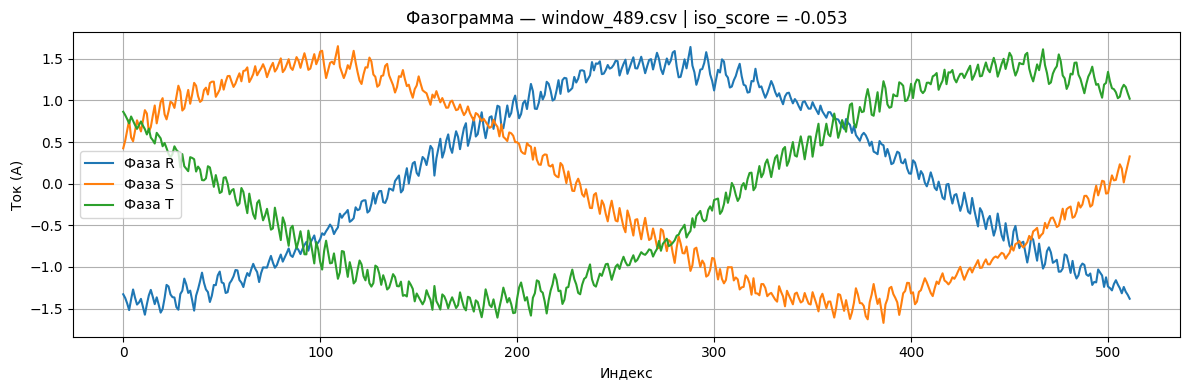

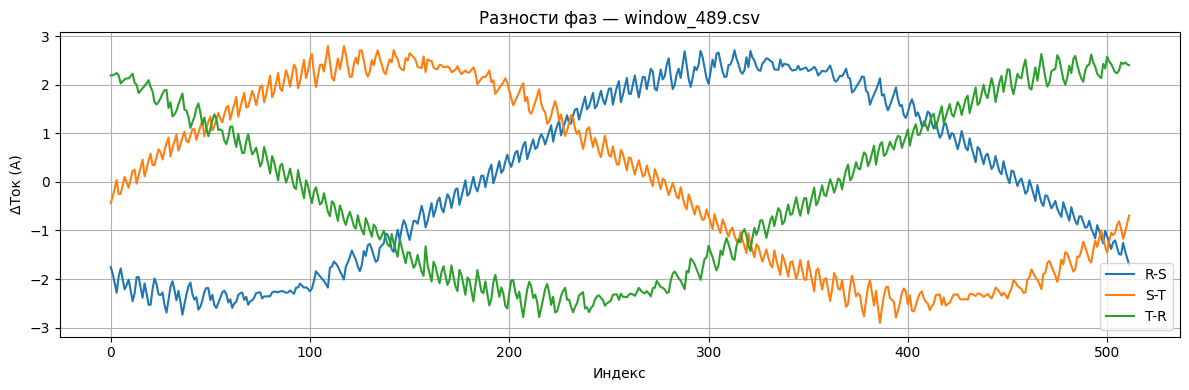

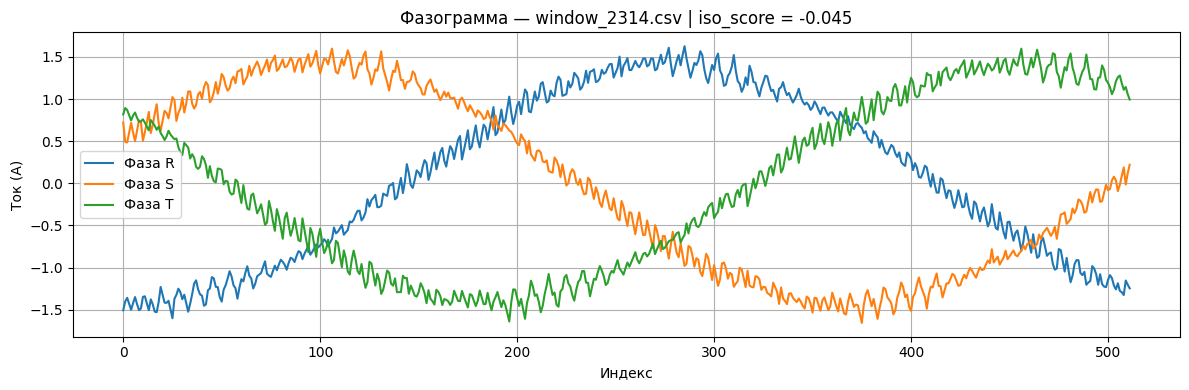

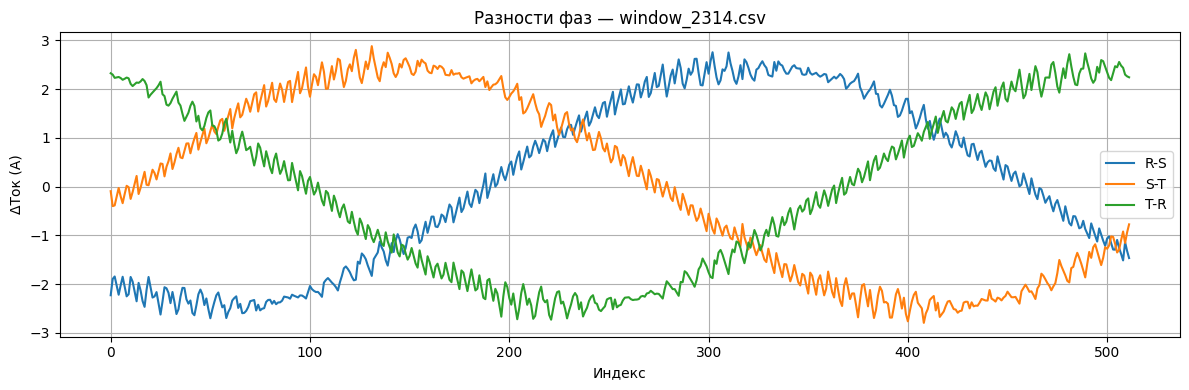

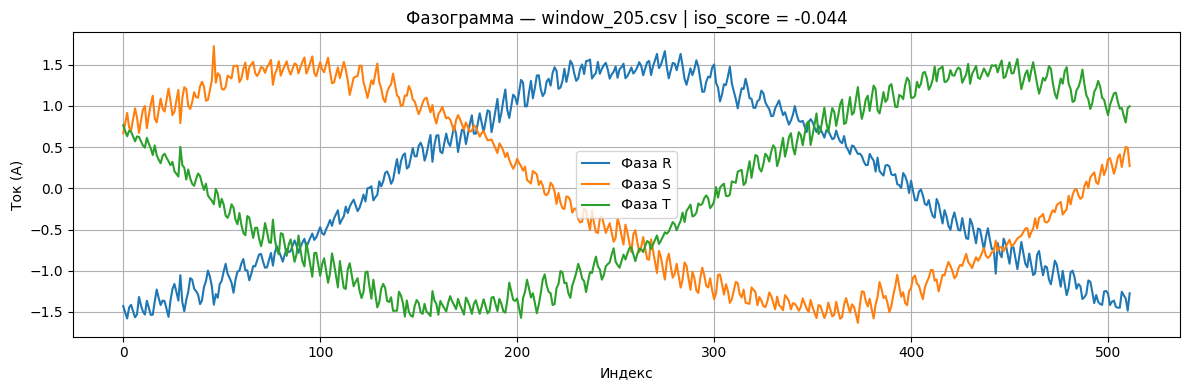

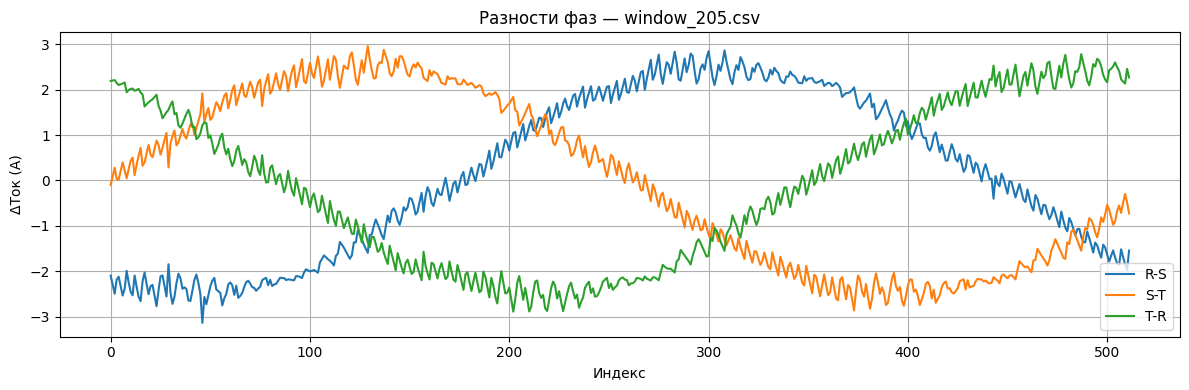

In [19]:
# Пример: визуализируем первые 3 окна из топа Isolation Forest
for i in range(min(3, len(top_iso))):
    row = top_iso.iloc[i]
    plot_window(row["window_file"], title_extra=f"| iso_score = {row['iso_score']:.3f}")